In [1]:
%pip install prophet
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet

Note: you may need to restart the kernel to use updated packages.


In [10]:
df=pd.read_csv("updated.csv")
df['Created On']=pd.to_datetime(df['Created On'])
df['Month']=df['Created On'].dt.to_period('M').dt.to_timestamp()

In [11]:
monthly_counts=df.groupby('Month').size().reset_index(name='task_count')


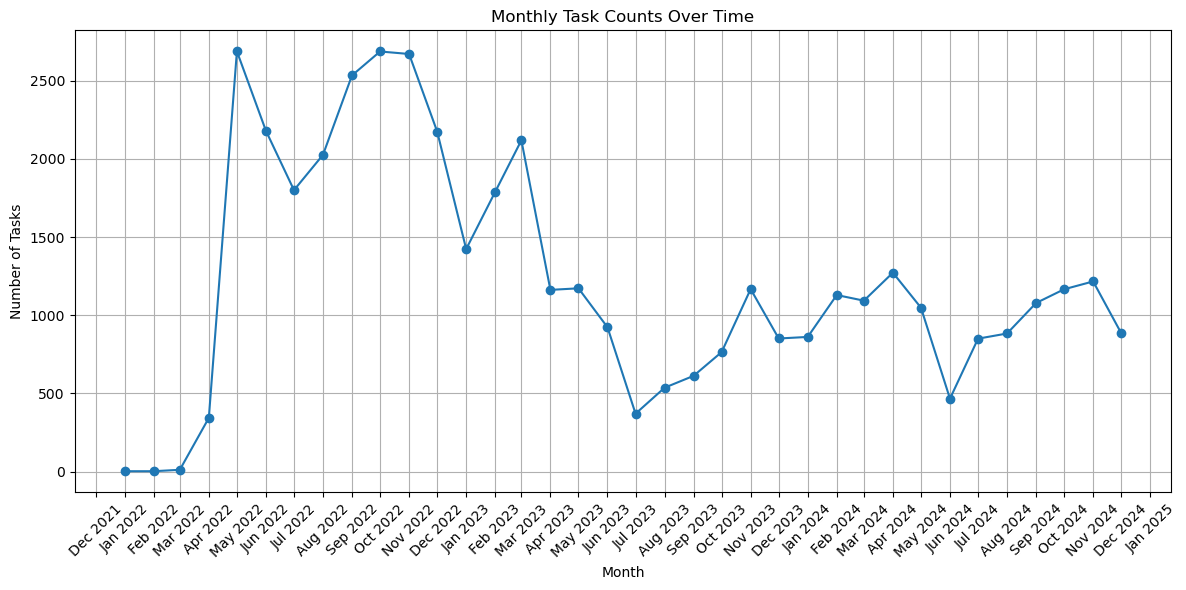

In [14]:
# import matplotlib.dates as mdates
plt.figure(figsize=(12, 6))
plt.plot(monthly_counts['Month'], monthly_counts['task_count'], marker='o')
plt.title('Monthly Task Counts Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Tasks')
plt.grid(True)

# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
# plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
# plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

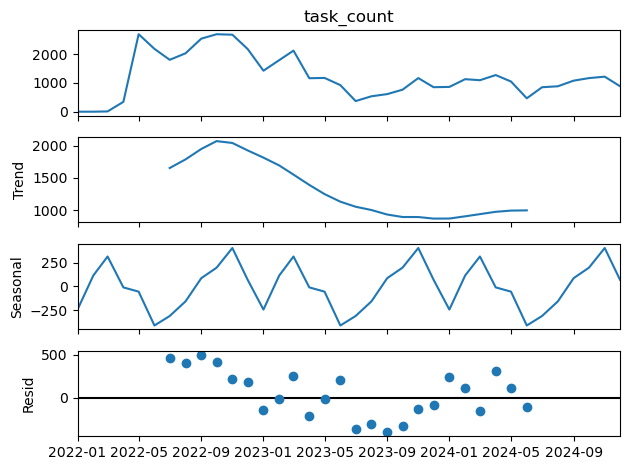

In [15]:
result = seasonal_decompose(monthly_counts.set_index('Month')['task_count'], model='additive', period=12)
result.plot()
plt.tight_layout()
plt.show()

In [16]:
prophet_df = monthly_counts.rename(columns={'Month': 'ds', 'task_count': 'y'})

In [17]:
model = Prophet()
model.fit(prophet_df)

17:19:09 - cmdstanpy - INFO - Chain [1] start processing
17:19:10 - cmdstanpy - INFO - Chain [1] done processing


In [20]:
future = model.make_future_dataframe(periods=12, freq='ME')
forecast = model.predict(future)

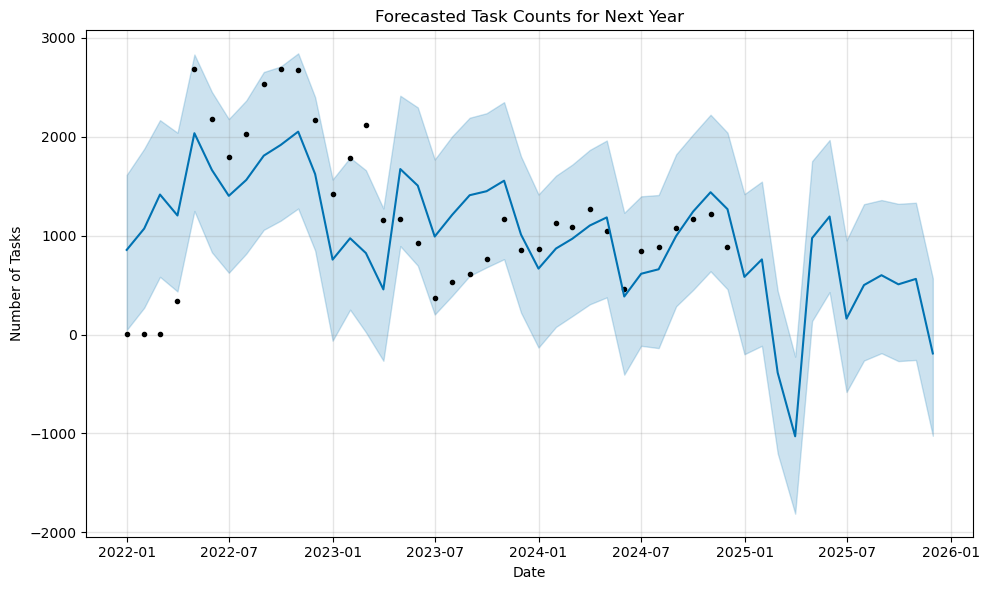

In [22]:
model.plot(forecast)
plt.title('Forecasted Task Counts for Next Year')
plt.xlabel('Date')
plt.ylabel('Number of Tasks')
plt.tight_layout()
plt.show()

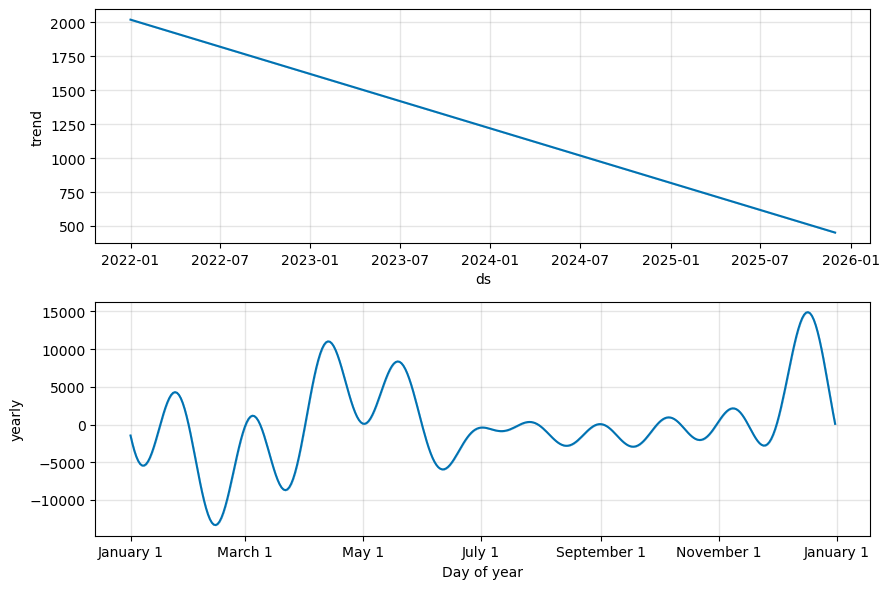

In [23]:
model.plot_components(forecast)
plt.tight_layout()
plt.show()


In [25]:
forecast_2025 = forecast[forecast['ds'].dt.year == 2025][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
print("Forecasted Task Counts for 2025:\n", forecast_2025)

Forecasted Task Counts for 2025:
            ds         yhat   yhat_lower   yhat_upper
37 2025-01-31   760.640513  -113.179077  1547.100741
38 2025-02-28  -385.289935 -1200.541692   441.468564
39 2025-03-31 -1028.628083 -1811.170730  -222.949657
40 2025-04-30   976.036585   136.238889  1754.140878
41 2025-05-31  1194.272869   429.500912  1967.748310
42 2025-06-30   161.902843  -580.648633   952.860757
43 2025-07-31   500.973646  -262.250847  1318.829401
44 2025-08-31   600.656397  -188.068202  1360.935373
45 2025-09-30   508.534342  -267.955675  1322.627566
46 2025-10-31   563.370604  -256.380246  1333.538334
47 2025-11-30  -190.598088 -1023.637232   568.959363
